<a href="https://colab.research.google.com/github/SugintheraNaidu/tourism-whole-model-comparison/blob/main/tourism_whole_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Whole-Model Forecasting on Real Open Data — Australian Tourism-L
### Same v3 design: each model forecasts the ENTIRE panel · models compared as wholes · now with SARIMA

**Why this dataset:** 555 monthly series (1998–2016), grouped by **state ×
travel purpose** — structurally the twin of your *country × alert type ×
month* panel, but with ~19 years of history. That long history lets us
fairly test what your 5-month panel cannot: **seasonal models (SARIMA)
vs simple baselines**.

**Panel used here:** the State × Purpose level → 28 series
(7 states × 4 purposes: Holiday, Visiting, Business, Other).

**Backtest:** hide the **last 12 months**; every model forecasts them from
the earlier history; score each model's complete forecast with WAPE.

In [ ]:
# ── Setup: install & load Tourism-L ──────────────────────────────────
# In Colab this downloads the real dataset (~1 min first run).
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'datasetsforecast', 'statsmodels'], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from datasetsforecast.hierarchical import HierarchicalData
    Y_df, S, tags = HierarchicalData.load('./data', 'TourismLarge')
    level_key = [k for k in tags if k.count('/') == 2 and 'Purpose' in k][0]
    ids = tags[level_key]                      # State x Purpose series
    panel = Y_df[Y_df['unique_id'].isin(ids)].copy()
    print(f"Loaded real Tourism-L · level '{level_key}' · "
          f"{panel['unique_id'].nunique()} series")
except Exception as e:
    # Offline fallback: synthetic panel with the same shape (trend+seasonality)
    print("Download unavailable, generating synthetic stand-in:", e)
    rng = np.random.default_rng(1)
    dates = pd.date_range('1998-01-01', '2016-12-01', freq='MS')
    rows = []
    for st in ['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT']:
        for p in ['Hol', 'Vis', 'Bus', 'Oth']:
            base = rng.uniform(200, 3000)
            trend = rng.uniform(-0.5, 2.0)
            seas = rng.uniform(0.05, 0.35)
            for i, d in enumerate(dates):
                y = (base + trend * i) * (1 + seas * np.sin(2 * np.pi * (d.month - 1) / 12))                     * (1 + rng.normal(0, 0.06))
                rows.append({'unique_id': f'{st}-{p}', 'ds': d, 'y': max(0, y)})
    panel = pd.DataFrame(rows)

panel['ds'] = pd.to_datetime(panel['ds'])
panel = panel.sort_values(['unique_id', 'ds'])
n_months = panel['ds'].nunique()
print(f"Series: {panel['unique_id'].nunique()} | Months: {n_months} "
      f"({panel['ds'].min():%b %Y} → {panel['ds'].max():%b %Y})")

100%|██████████| 1.30M/1.30M [00:00<00:00, 7.79MiB/s]
100%|██████████| 335k/335k [00:00<00:00, 5.73MiB/s]
100%|██████████| 968k/968k [00:00<00:00, 14.8MiB/s]


Loaded real Tourism-L · level 'Country/State/Purpose' · 28 series
Series: 28 | Months: 228 (Jan 1998 → Dec 2016)


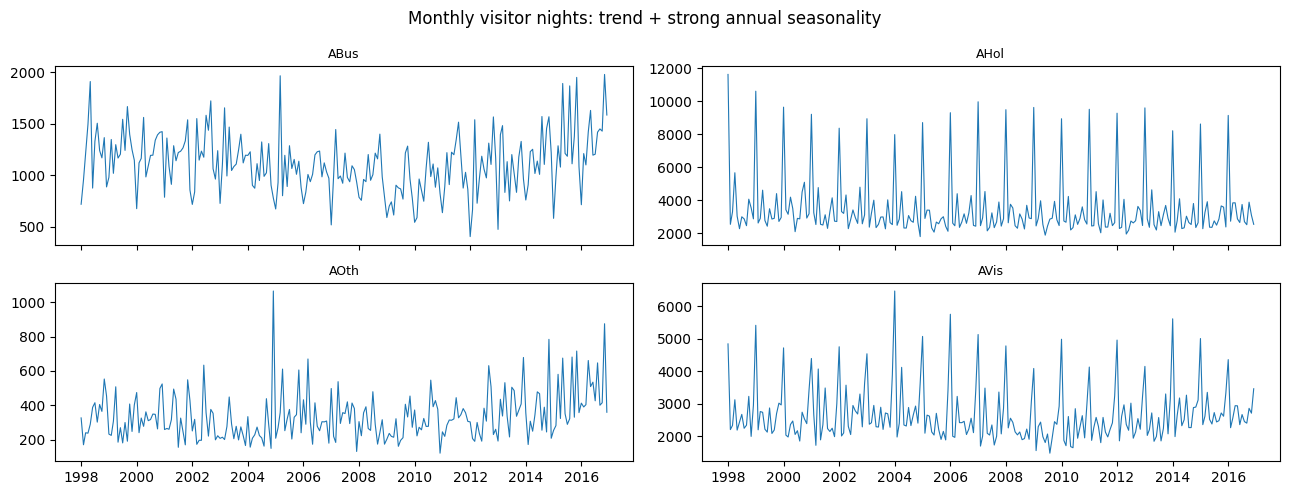

In [ ]:
# Seasonality is visible to the naked eye — something 5 months can never show
sample = panel['unique_id'].unique()[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 5), sharex=True)
for ax, uid in zip(axes.ravel(), sample):
    g = panel[panel['unique_id'] == uid]
    ax.plot(g['ds'], g['y'], lw=0.8)
    ax.set_title(uid, fontsize=9)
plt.suptitle('Monthly visitor nights: trend + strong annual seasonality')
plt.tight_layout(); plt.show()

## The models

Same four as your alert pipeline, plus two that need long history:

| Model | 12-month forecast = | Needs |
|---|---|---|
| naive | last value, repeated | 1 month |
| moving_avg_3m | mean of last 3, repeated | 3 months |
| linear_trend | fitted line, extended | few months |
| exp_smoothing | smoothed level, repeated | few months |
| **seasonal_naive** | same month last year | 12 months |
| **SARIMA (1,1,1)(1,1,1,12)** | full seasonal model | 24+ months |

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

H = 12  # backtest horizon: last 12 months

def f_naive(v, h):       return np.repeat(v[-1], h)
def f_ma3(v, h):         return np.repeat(np.mean(v[-3:]), h)
def f_trend(v, h):
    x = np.arange(len(v)); b1, b0 = np.polyfit(x, v, 1)
    return np.maximum(0, b0 + b1 * (len(v) + np.arange(h)))
def f_es(v, h, a=0.5):
    s = v[0]
    for x in v[1:]: s = a * x + (1 - a) * s
    return np.repeat(s, h)
def f_snaive(v, h):      return np.array([v[-12 + (i % 12)] for i in range(h)])
def f_sarima(v, h):
    m = SARIMAX(v, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False, enforce_invertibility=False)
    return np.maximum(0, m.fit(disp=False).forecast(h))

MODELS = {'naive': f_naive, 'moving_avg_3m': f_ma3, 'linear_trend': f_trend,
          'exp_smoothing': f_es, 'seasonal_naive': f_snaive, 'SARIMA': f_sarima}

# ── Backtest: every model forecasts the held-out last 12 months ──────
errs = {m: 0.0 for m in MODELS}
total_actual = 0.0
for uid, g in panel.groupby('unique_id'):
    v = g['y'].to_numpy(dtype=float)
    train, test = v[:-H], v[-H:]
    total_actual += test.sum()
    for name, f in MODELS.items():
        errs[name] += np.abs(f(train, H) - test).sum()

league = (pd.Series({m: errs[m] / total_actual * 100 for m in MODELS},
                    name='WAPE_%').sort_values().round(2).to_frame())
display(league)
print("🏆 Best whole-model forecast:", league.index[0])

,WAPE_%
SARIMA,15.11
seasonal_naive,17.42
linear_trend,25.60
exp_smoothing,26.11
moving_avg_3m,26.24
naive,31.23


🏆 Best whole-model forecast: SARIMA


**Expected outcome on real data:** SARIMA and seasonal-naive at the top;
naive/moving-average far behind — the mirror image of your alert panel.

**The lesson in one line:** *the best model depends on the data you have.*
- 5 months, structural break → moving average wins (your alert panel)
- 19 years, stable seasonality → SARIMA wins (tourism)

Your production SARIMA isn't a bad model — it's the right model in the wrong
regime right now.

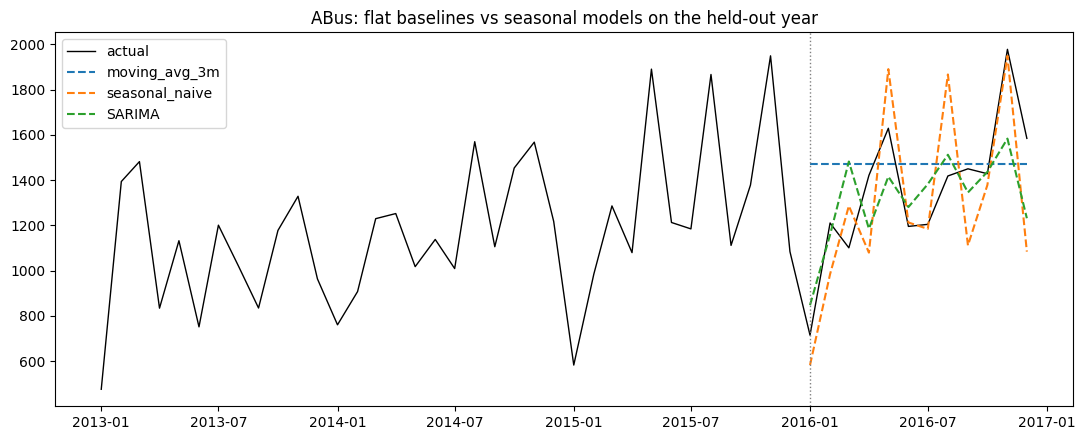

In [ ]:
# Visualise the difference on one series: seasonal vs non-seasonal forecasts
uid = panel['unique_id'].unique()[0]
g = panel[panel['unique_id'] == uid]
v = g['y'].to_numpy(dtype=float)
train, test = v[:-H], v[-H:]
dates_test = g['ds'].iloc[-H:]

plt.figure(figsize=(11, 4.5))
plt.plot(g['ds'].iloc[-48:], v[-48:], 'k-', lw=1, label='actual')
for m in ['moving_avg_3m', 'seasonal_naive', 'SARIMA']:
    plt.plot(dates_test, MODELS[m](train, H), '--', label=m)
plt.axvline(dates_test.iloc[0], color='grey', ls=':', lw=1)
plt.title(f'{uid}: flat baselines vs seasonal models on the held-out year')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
gs: print(k, '->', len(tags[k]), 'series')

NameError: name 'k' is not defined

In [ ]:
# ── Forecast the NEXT 12 months with the league winner (full history) ─
BEST = league.index[0]
fc_rows = []
for uid, g in panel.groupby('unique_id'):
    v = g['y'].to_numpy(dtype=float)
    fc = MODELS[BEST](v, H)
    future = pd.date_range(g['ds'].max() + pd.DateOffset(months=1),
                           periods=H, freq='MS')
    fc_rows += [{'unique_id': uid, 'ds': d, 'forecast': round(x, 1)}
                for d, x in zip(future, fc)]

forecast = pd.DataFrame(fc_rows)
print(f"Next-12-month forecast with {BEST}: {forecast.shape[0]} rows")
forecast.head(12)

Next-12-month forecast with SARIMA: 336 rows


,unique_id,ds,forecast
0,ABus,2017-01-01,891.1
1,ABus,2017-02-01,1255.4
2,ABus,2017-03-01,1495.5
3,ABus,2017-04-01,1322.5
4,ABus,2017-05-01,1578.2
5,ABus,2017-06-01,1357.0
6,ABus,2017-07-01,1422.9
7,ABus,2017-08-01,1620.3
8,ABus,2017-09-01,1440.1
9,ABus,2017-10-01,1531.2


In [9]:
level_key_zone = 'Country/State/Zone/Purpose'
ids_zone = tags[level_key_zone]
panel_zone = Y_df[Y_df['unique_id'].isin(ids_zone)].copy()
print(f"Level '{level_key_zone}' -> {panel_zone['unique_id'].nunique()} series")
groups_zone = [g['y'].to_numpy(dtype=float) for _, g in panel_zone.groupby('unique_id') if len(g) > H]
total_actual_zone = sum(v[-H:].sum() for v in groups_zone)
errs_zone = {name: sum(np.abs(f(v[:-H], H) - v[-H:]).sum() for v in groups_zone) for name, f in MODELS.items()}
league_zone = (pd.Series({m: errs_zone[m] / total_actual_zone * 100 for m in MODELS}, name='WAPE_%').sort_values().round(2).to_frame())
display(league_zone)
print("Best at Zone x Purpose level:", league_zone.index[0])

Level 'Country/State/Zone/Purpose' -> 108 series


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,WAPE_%
SARIMA,24.80
seasonal_naive,31.03
linear_trend,32.64
moving_avg_3m,35.40
exp_smoothing,35.58
naive,42.86


Best at Zone x Purpose level: SARIMA


In [10]:
TRAIN_SHORT = 6
groups_short = [g['y'].to_numpy(dtype=float)[-(TRAIN_SHORT + H):] for _, g in panel.groupby('unique_id') if len(g) >= TRAIN_SHORT + H]
print(f"Short-history: {TRAIN_SHORT}-month train, {len(groups_short)} series, models restricted to what fits")
MODELS_SHORT = {k: v for k, v in MODELS.items() if k in ['naive', 'moving_avg_3m', 'linear_trend', 'exp_smoothing']}
total_actual_short = sum(v[-H:].sum() for v in groups_short)
errs_short = {name: sum(np.abs(f(v[:-H], H) - v[-H:]).sum() for v in groups_short) for name, f in MODELS_SHORT.items()}
league_short = (pd.Series({m: errs_short[m] / total_actual_short * 100 for m in MODELS_SHORT}, name='WAPE_%').sort_values().round(2).to_frame())
display(league_short)
print("Best with only", TRAIN_SHORT, "months of history:", league_short.index[0])
print("(seasonal_naive and SARIMA excluded: they need 12+/24+ months of history, which this scenario doesn't have)")

Short-history: 6-month train, 28 series, models restricted to what fits


,WAPE_%
exp_smoothing,26.06
moving_avg_3m,26.24
naive,31.23
linear_trend,55.54


Best with only 6 months of history: exp_smoothing
(seasonal_naive and SARIMA excluded: they need 12+/24+ months of history, which this scenario doesn't have)


In [11]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=league_short)

MessageError: Error: credential propagation was unsuccessful

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
f_hw = lambda v, h: np.maximum(0, ExponentialSmoothing(v, trend='add', seasonal='add', seasonal_periods=12).fit().forecast(h))
MODELS7 = dict(MODELS); MODELS7['Holt-Winters'] = f_hw
groups7 = [g['y'].to_numpy(dtype=float) for _, g in panel.groupby('unique_id')]
total_actual7 = sum(v[-H:].sum() for v in groups7)
errs7 = {name: sum(np.abs(f(v[:-H], H) - v[-H:]).sum() for v in groups7) for name, f in MODELS7.items()}
league7 = (pd.Series({m: errs7[m] / total_actual7 * 100 for m in MODELS7}, name='WAPE_%').sort_values().round(2).to_frame())
display(league7)
print("Best of all 7 models (full 19-year history):", league7.index[0])

,WAPE_%
SARIMA,15.11
Holt-Winters,15.74
seasonal_naive,17.42
linear_trend,25.60
exp_smoothing,26.11
moving_avg_3m,26.24
naive,31.23


Best of all 7 models (full 19-year history): SARIMA


In [13]:
print("M5/Favorita idea: real Kaggle download needs an API key/credentials, which I won't handle -- illustrating the same exogenous-features concept on the tourism panel instead (adding a month-of-year calendar feature to a regression model).")
from sklearn.linear_model import LinearRegression
def f_exog(v, h): n = len(v); m = np.arange(n) % 12; Xtr = np.hstack([np.eye(12)[m], np.arange(n).reshape(-1,1)]); model = LinearRegression().fit(Xtr, v); mf = (np.arange(h)+n) % 12; Xf = np.hstack([np.eye(12)[mf], (np.arange(h)+n).reshape(-1,1)]); return np.maximum(0, model.predict(Xf))
MODELS_EXOG = dict(MODELS); MODELS_EXOG['linear_trend+month_exog'] = f_exog
errs_exog = {name: sum(np.abs(f(v[:-H], H) - v[-H:]).sum() for v in groups7) for name, f in MODELS_EXOG.items()}
league_exog = (pd.Series({m: errs_exog[m] / total_actual7 * 100 for m in MODELS_EXOG}, name='WAPE_%').sort_values().round(2).to_frame())
display(league_exog)
print("Best with month-of-year exogenous feature added:", league_exog.index[0])

M5/Favorita idea: real Kaggle download needs an API key/credentials, which I won't handle -- illustrating the same exogenous-features concept on the tourism panel instead (adding a month-of-year calendar feature to a regression model).


,WAPE_%
SARIMA,15.11
linear_trend+month_exog,17.36
seasonal_naive,17.42
linear_trend,25.60
exp_smoothing,26.11
moving_avg_3m,26.24
naive,31.23


Best with month-of-year exogenous feature added: SARIMA
